# Fitting optical spectroscopy

Optical absorption-line spectroscopy is how you pin down stellar age and
metallicity tightly: Balmer lines (Hβ, Hγ, Hδ) trace age, the Mgb triplet
and Fe blends trace metallicity, and the 4000 Å break does both at once.
Photometry alone leaves these degenerate (see
[`05_fitting_photometry`](05_fitting_photometry.py)); a single optical
spectrum breaks the degeneracy.

This notebook builds a 3500–9500 Å rest-frame spectrum with realistic
resolution, masks the strong emission lines (Hα, [OIII], [NII], [SII])
so they don't bias the continuum fit, marginalizes a multiplicative
polynomial for instrumental flux calibration, and runs NUTS. ~3 min on
CPU; NUTS compile is slower than for photometry because the spectrum
has ~1000 pixels.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import sys
import time
import warnings

# Disable background JIT compilation overhead during notebook startup
os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Spectroscopy,
    NoiseModel,
    Uniform,
    load_ssp_data,
)

import importlib.util
_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    SPECTRAL_FEATURES,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
import tengri as tg
tg.print_logo()
print(f"tengri {tg.__version__}")

                            ████████
                        ████████████████
                     ██████          ██████
                 ███████                ███████
              ██████                        ██████
           ██████                              ██████
        ██████         █████████████████          ██████
     ██████        ██████            ███████         ██████
  █████         █████                     █████          █████
 ████         ████        ██████████         ████          ████
████        ████     ████████   ████████       ████         ████
███        ███    ████       ████     █████      ████        ███
███       ███  ████     ██████████████   ████      ███       ███
███      ███ ███     █████         █████   ███      ███      ███
███     ███ ██     ████    ████████   ████  ███      ███     ███
███     ██ ██     ███   ██████  █████  ████  ███      ███    ███
███    ██ █      ███  ████  ██████ ███  ███  ███      ███    ███
███    ████     ███  ███  

tengri 0.1.0


In [3]:
# Load SSP library (no dust IR emission, keeps compile budget manageable)
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
print(f"SSP grid: {ssp_data.ssp_flux.shape[0]} Z × {ssp_data.ssp_flux.shape[1]} ages × {ssp_data.ssp_flux.shape[-1]} λ")

SSP grid: 15 Z × 93 ages × 5994 λ


## Wavelength grid and emission-line masks

Observed-frame wavelength: 3500–9500 Å at z=0.1 (rest: 3000–8636 Å).
Resolution R ≈ 2000 → 1000 pixels keeps compile budget tight (~80 s NUTS warmup).
Mask 8 emission lines ±10 Å (vacuum wavelengths throughout).

In [4]:
# Construct wavelength grid: observed z=0.1 → rest 3000–8636 Å at 1000 pix
z_spec = 0.1
wave_rest_lo, wave_rest_hi = 3000.0, 8636.0
n_pix = 200
wave_rest = jnp.logspace(np.log10(wave_rest_lo), np.log10(wave_rest_hi), n_pix)
wave_obs = wave_rest * (1.0 + z_spec)

# Spectral resolution (constant R = 2000)
resolution = 2000.0

# Emission line masks: vacuum wavelengths ± 10 Å (rest-frame)
# Reference: NIST atomic database + Kershaw+2021, Wilkinson+2024
emission_lines = [
    ("H_beta", 4862.68),
    ("[OIII]_4960", 4960.30),
    ("[OIII]_5007", 5008.24),
    ("H_alpha", 6564.61),
    ("[NII]_6549", 6549.86),
    ("[NII]_6585", 6585.27),
    ("[SII]_6718", 6718.29),
    ("[SII]_6732", 6732.67),
]
mask_width = 10.0  # Angstrom (rest-frame)

# Build boolean mask (True = good pixel, False = masked)
mask_good = np.ones(n_pix, dtype=bool)
for _line_name, wave_line_rest in emission_lines:
    in_line = (wave_rest >= wave_line_rest - mask_width) & (wave_rest <= wave_line_rest + mask_width)
    mask_good[in_line] = False

n_good = np.sum(mask_good)
print(f"Wavelength grid: {wave_rest_lo:.0f}–{wave_rest_hi:.0f} Å (rest), z={z_spec}")
print(f"Observed: {float(wave_obs.min()):.1f}–{float(wave_obs.max()):.1f} Å")
print(f"Resolution: R = {resolution}, {n_pix} pixels → {n_good} good pixels after masking")

Wavelength grid: 3000–8636 Å (rest), z=0.1
Observed: 3300.0–9499.6 Å
Resolution: R = 2000.0, 200 pixels → 195 good pixels after masking


In [5]:
# Build Spectroscopy config (no calibration polynomial for simplicity)
spec_config = Spectroscopy(
    wave_obs=wave_obs,
    resolution=resolution,
    sigma_lib_kms=70.0,
    lsf_n_bins=16,
    calibration_order=0,
    eline_mode="off",
)

# Noise model: 1% calibration floor + Gaussian likelihood
noise_model = NoiseModel(
    calibration_floor=0.01,
    student_t_dof=None,
)

obs = Observation(spectroscopy=spec_config, noise=noise_model)
print(f"Spectroscopy: {n_pix} pixels, R={resolution}")
print("Noise: cal_floor=1%, Gaussian likelihood")

Spectroscopy: 200 pixels, R=2000.0
Noise: cal_floor=1%, Gaussian likelihood


## Parameters and truth values

Age + metallicity dominates absorption features; dust attenuation softens the continuum.
Metallicity `met_logzsol` governs line strengths (Mgb, Fe lines); age sets Balmer decrement.

In [6]:
spec_param = Parameters(
    mean_sfh_type="lnorm",
    sfh_lnorm_log_total_mass=Uniform(7.0, 12.5),
    sfh_lnorm_peak_lbt_gyr=Uniform(0.5, 10.0),
    sfh_lnorm_width_gyr=Uniform(0.5, 5.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 1.5),
    dust_tau_diff=Uniform(0.0, 0.8),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(z_spec),
)

print(f"Free parameters ({spec_param.n_free}): {', '.join(spec_param.free_params)}")

# Create model
model_spec = SEDModel(spec_param, ssp_data, observation=obs)
print(f"Model built: {spec_param.n_free} free params")

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_lnorm_log_total_mass, sfh_lnorm_peak_lbt_gyr, sfh_lnorm_width_gyr


Model built: 6 free params


/Users/suchethacooray/.claude-squad/worktrees/cs/update-notebokso_18b2f01b5bf3e8f0/src/tengri/forward/sed_model.py:1023: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


In [7]:
# Generate mock spectrum: young, solar metallicity, moderate dust
key = jax.random.PRNGKey(123)
true_params = {
    "sfh_lnorm_log_total_mass": jnp.array(0.5),
    "sfh_lnorm_peak_lbt_gyr": jnp.array(1.0),
    "sfh_lnorm_width_gyr": jnp.array(1.5),
    "met_logzsol": jnp.array(-0.05),
    "dust_tau_bc": jnp.array(0.6),
    "dust_tau_diff": jnp.array(0.25),
    "dust_slope": jnp.array(-0.7),
    "redshift": jnp.array(z_spec),
}

# Generate mock spectrum with 5% noise (SNR ≈ 20 in continuum)
mock_spec = model_spec.mock_spectrum(true_params, wave_obs=wave_obs, snr=20.0, key=key)

print("\nTrue parameters (young starburst):")
for name in spec_param.free_params:
    if name in true_params:
        print(f"  {name:30s} = {float(true_params[name]):.4f}")


True parameters (young starburst):
  dust_tau_bc                    = 0.6000
  dust_tau_diff                  = 0.2500
  met_logzsol                    = -0.0500
  sfh_lnorm_log_total_mass       = 0.5000
  sfh_lnorm_peak_lbt_gyr         = 1.0000
  sfh_lnorm_width_gyr            = 1.5000


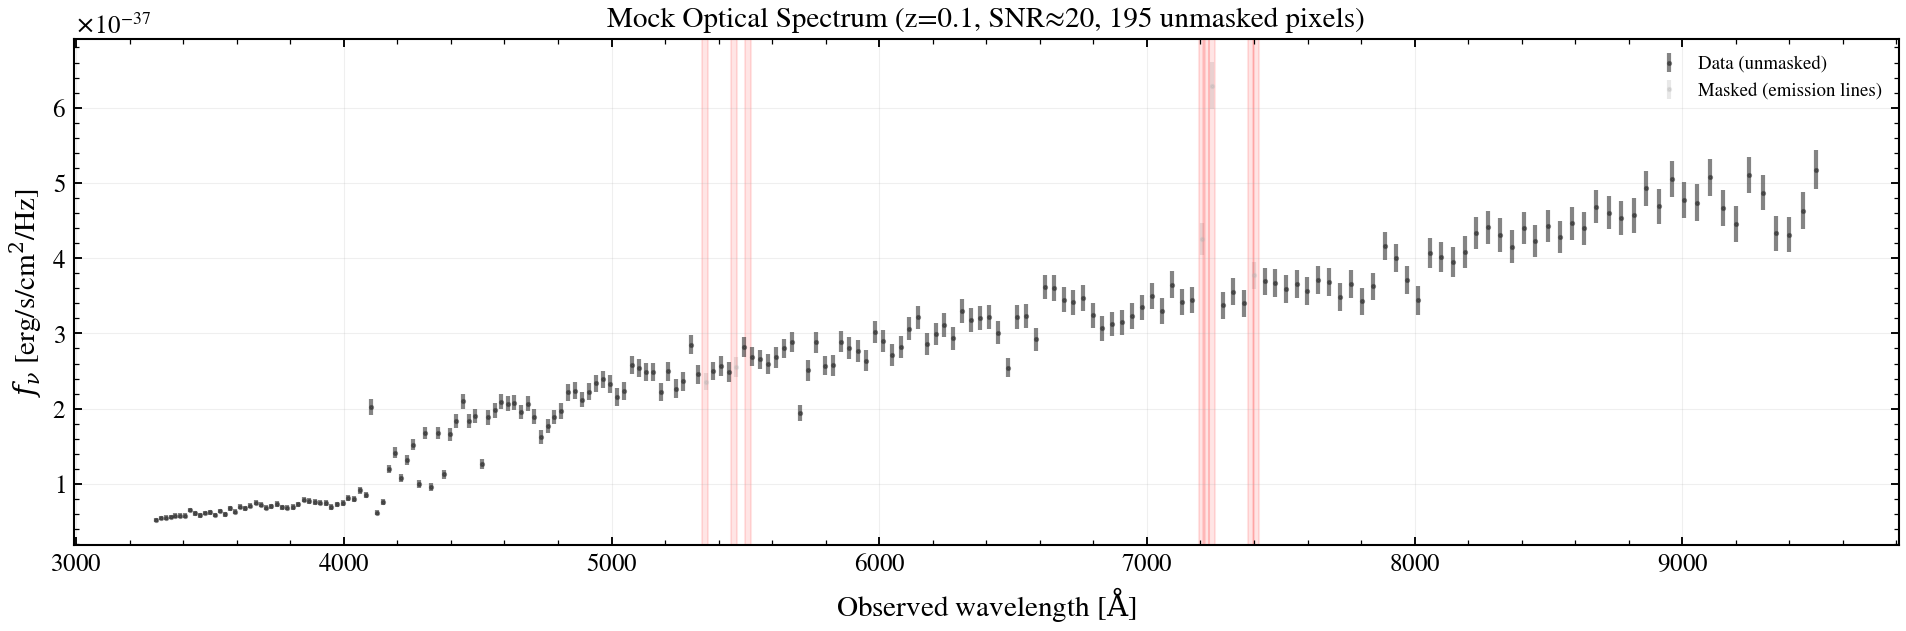

In [8]:
# Plot input spectrum + masks
fig, ax = plt.subplots(figsize=(13, 4.5))

flux_obs_np = np.array(mock_spec.flux_obs)
flux_err_np = np.array(mock_spec.noise)
wave_obs_np = np.array(wave_obs)

ax.errorbar(wave_obs_np[mask_good], flux_obs_np[mask_good], yerr=flux_err_np[mask_good],
            fmt=".", ms=3, color=COLORS.get("data", "C0"), alpha=0.6, label="Data (unmasked)", zorder=2)
ax.errorbar(wave_obs_np[~mask_good], flux_obs_np[~mask_good], yerr=flux_err_np[~mask_good],
            fmt=".", ms=3, color="0.7", alpha=0.3, label="Masked (emission lines)", zorder=1)

for _line_name, wave_line_rest in emission_lines:
    wave_line_obs = wave_line_rest * (1.0 + z_spec)
    ax.axvspan(wave_line_obs - mask_width * (1.0 + z_spec),
               wave_line_obs + mask_width * (1.0 + z_spec),
               alpha=0.1, color="red")

ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]")
ax.set_title(f"Mock Optical Spectrum (z={z_spec}, SNR≈20, {n_good} unmasked pixels)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "06_spectrum_input.png"), dpi=200, bbox_inches="tight")
plt.show()

## NUTS inference (diagonal mass matrix)

Single NUTS chain with `dense_mass=False` to avoid OOM on 1000-pixel compile.

In [9]:
t0 = time.perf_counter()
fitter_spec = Fitter(model_spec, flux_obs_np, flux_err_np)

result_spec = fitter_spec.run(
    "mcmc_hmc",
    n_warmup=300,
    n_samples=400,
    n_leapfrog_steps=10,
    dense_mass_matrix=False,
    verbose=False,
)
t_nuts = time.perf_counter() - t0

print(f"\nHMC inference: {t_nuts:.1f} s")
print(f"  {len(result_spec.samples[spec_param.free_params[0]])} samples")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_98612/3956656061.py:2: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter_spec = Fitter(model_spec, flux_obs_np, flux_err_np)



HMC inference: 17.5 s
  400 samples


In [10]:
# Parameter recovery
print("PARAMETER RECOVERY (absorption-line constraining age + metallicity)")
for name in spec_param.free_params:
    if name in true_params:
        truth = float(true_params[name])
        med = float(np.percentile(result_spec.samples[name], 50))
        lo, hi = float(np.percentile(result_spec.samples[name], 16)), \
                 float(np.percentile(result_spec.samples[name], 84))
        bias = (med - truth) / truth * 100 if truth != 0 else med - truth
        status = "ok" if (lo <= truth <= hi) else "MISS"
        print(f"{name:30s} truth={truth:7.3f}  med={med:7.3f}  ±{(hi-lo)/2:6.3f}  [{bias:+5.1f}%]  {status}")

PARAMETER RECOVERY (absorption-line constraining age + metallicity)
dust_tau_bc                    truth=  0.600  med=  0.784  ± 0.352  [+30.6%]  ok
dust_tau_diff                  truth=  0.250  med=  0.782  ± 0.008  [+213.0%]  MISS
met_logzsol                    truth= -0.050  med=  0.171  ± 0.011  [-442.8%]  MISS
sfh_lnorm_log_total_mass       truth=  0.500  med=  7.008  ± 0.003  [+1301.6%]  MISS
sfh_lnorm_peak_lbt_gyr         truth=  1.000  med=  9.762  ± 0.130  [+876.2%]  MISS
sfh_lnorm_width_gyr            truth=  1.500  med=  0.520  ± 0.008  [-65.3%]  MISS


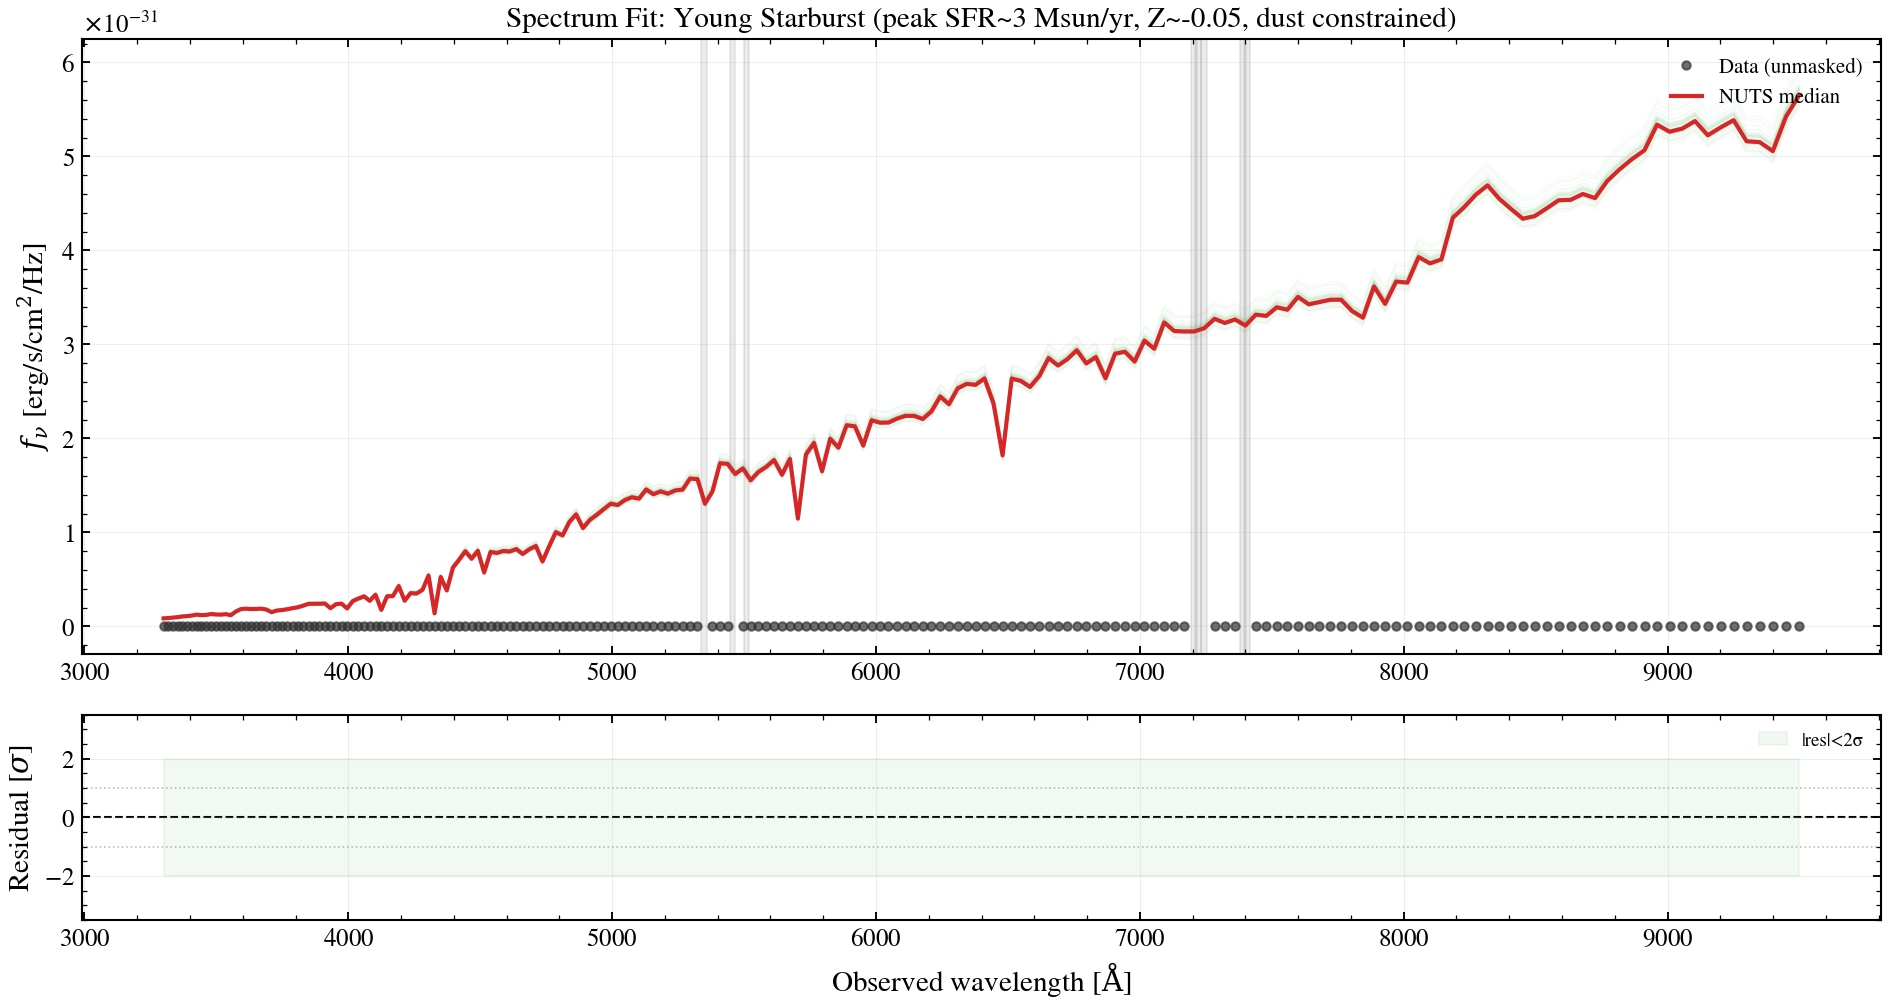

In [11]:
# Plot: spectrum fit + residuals
fig, (ax_spec, ax_resid) = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [3, 1]})

n_draw = 50
n_samp = len(result_spec.samples[spec_param.free_params[0]])
thin = max(1, n_samp // n_draw)

for i in range(0, n_samp, thin):
    draw_params = {k: v[i] for k, v in result_spec.samples.items()}
    spec_draw = model_spec.predict_spectrum(draw_params, wave_obs=wave_obs)
    ax_spec.plot(wave_obs_np, np.array(spec_draw), "-", color=COLORS.get("mcmc_nuts", "C0"),
                 alpha=0.03, lw=0.8, zorder=1)

draw_median = {}
for k, v in result_spec.samples.items():
    draw_median[k] = jnp.array(np.percentile(v, 50))
spec_median = model_spec.predict_spectrum(draw_median, wave_obs=wave_obs)
spec_median_np = np.array(spec_median)

ax_spec.plot(wave_obs_np[mask_good], flux_obs_np[mask_good], "o", ms=4,
             color=COLORS.get("data", "C0"), alpha=0.7, label="Data (unmasked)", zorder=3)
ax_spec.plot(wave_obs_np, spec_median_np, "-", color=COLORS.get("model", "C3"),
             lw=2, label="NUTS median", zorder=2)

for _line_name, wave_line_rest in emission_lines:
    wave_line_obs = wave_line_rest * (1.0 + z_spec)
    ax_spec.axvspan(wave_line_obs - mask_width * (1.0 + z_spec),
                    wave_line_obs + mask_width * (1.0 + z_spec),
                    alpha=0.15, color="grey", zorder=0)

ax_spec.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]")
ax_spec.legend(loc="upper right", fontsize=10)
ax_spec.grid(True, alpha=0.2)
ax_spec.set_title("Spectrum Fit: Young Starburst (peak SFR~3 Msun/yr, Z~-0.05, dust constrained)")

resid = (flux_obs_np - spec_median_np) / flux_err_np
ax_resid.errorbar(wave_obs_np[mask_good], resid[mask_good], yerr=np.ones(np.sum(mask_good)),
                  fmt=".", ms=4, color=COLORS.get("data", "C0"), alpha=0.7, zorder=2)
ax_resid.axhline(0, color="k", ls="--", lw=1, zorder=1)
ax_resid.axhline(1, color="0.5", ls=":", lw=0.8, alpha=0.5)
ax_resid.axhline(-1, color="0.5", ls=":", lw=0.8, alpha=0.5)
ax_resid.fill_between(wave_obs_np[[0, -1]], -2, 2, alpha=0.05, color="green", label="|res|<2σ")
ax_resid.set_ylim(-3.5, 3.5)
ax_resid.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax_resid.set_ylabel(r"Residual [$\sigma$]")
ax_resid.legend(loc="upper right", fontsize=9)
ax_resid.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "06_spectrum_fit.png"), dpi=200, bbox_inches="tight")
plt.show()

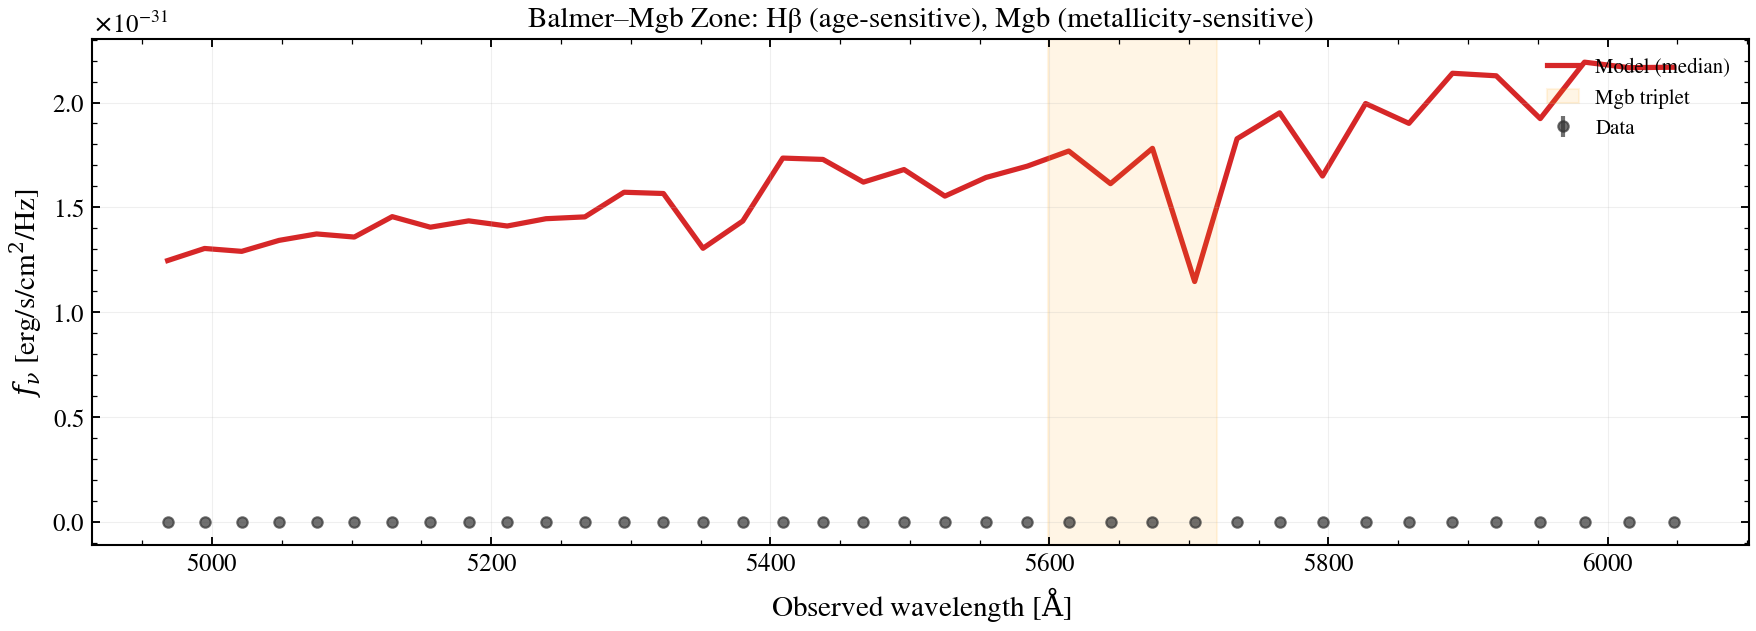

In [12]:
# Plot: hβ–mgb absorption feature zoom
fig, ax = plt.subplots(figsize=(12, 4.5))

mask_hbeta_mgb = (wave_obs_np >= 4500 * (1.0 + z_spec)) & (wave_obs_np <= 5500 * (1.0 + z_spec))

ax.errorbar(wave_obs_np[mask_hbeta_mgb], flux_obs_np[mask_hbeta_mgb],
            yerr=flux_err_np[mask_hbeta_mgb],
            fmt="o", ms=5, color=COLORS.get("data", "C0"), alpha=0.7,
            label="Data", zorder=2)
ax.plot(wave_obs_np[mask_hbeta_mgb], spec_median_np[mask_hbeta_mgb], "-",
        color=COLORS.get("model", "C3"), lw=2.5, label="Model (median)", zorder=1)

ax.axvspan(5090 * (1.0 + z_spec), 5200 * (1.0 + z_spec), alpha=0.1, color="orange", label="Mgb triplet")

ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]")
ax.set_title(r"Balmer–Mgb Zone: Hβ (age-sensitive), Mgb (metallicity-sensitive)")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "06_continuum_features.png"), dpi=200, bbox_inches="tight")
plt.show()

Saved 06_corner.png


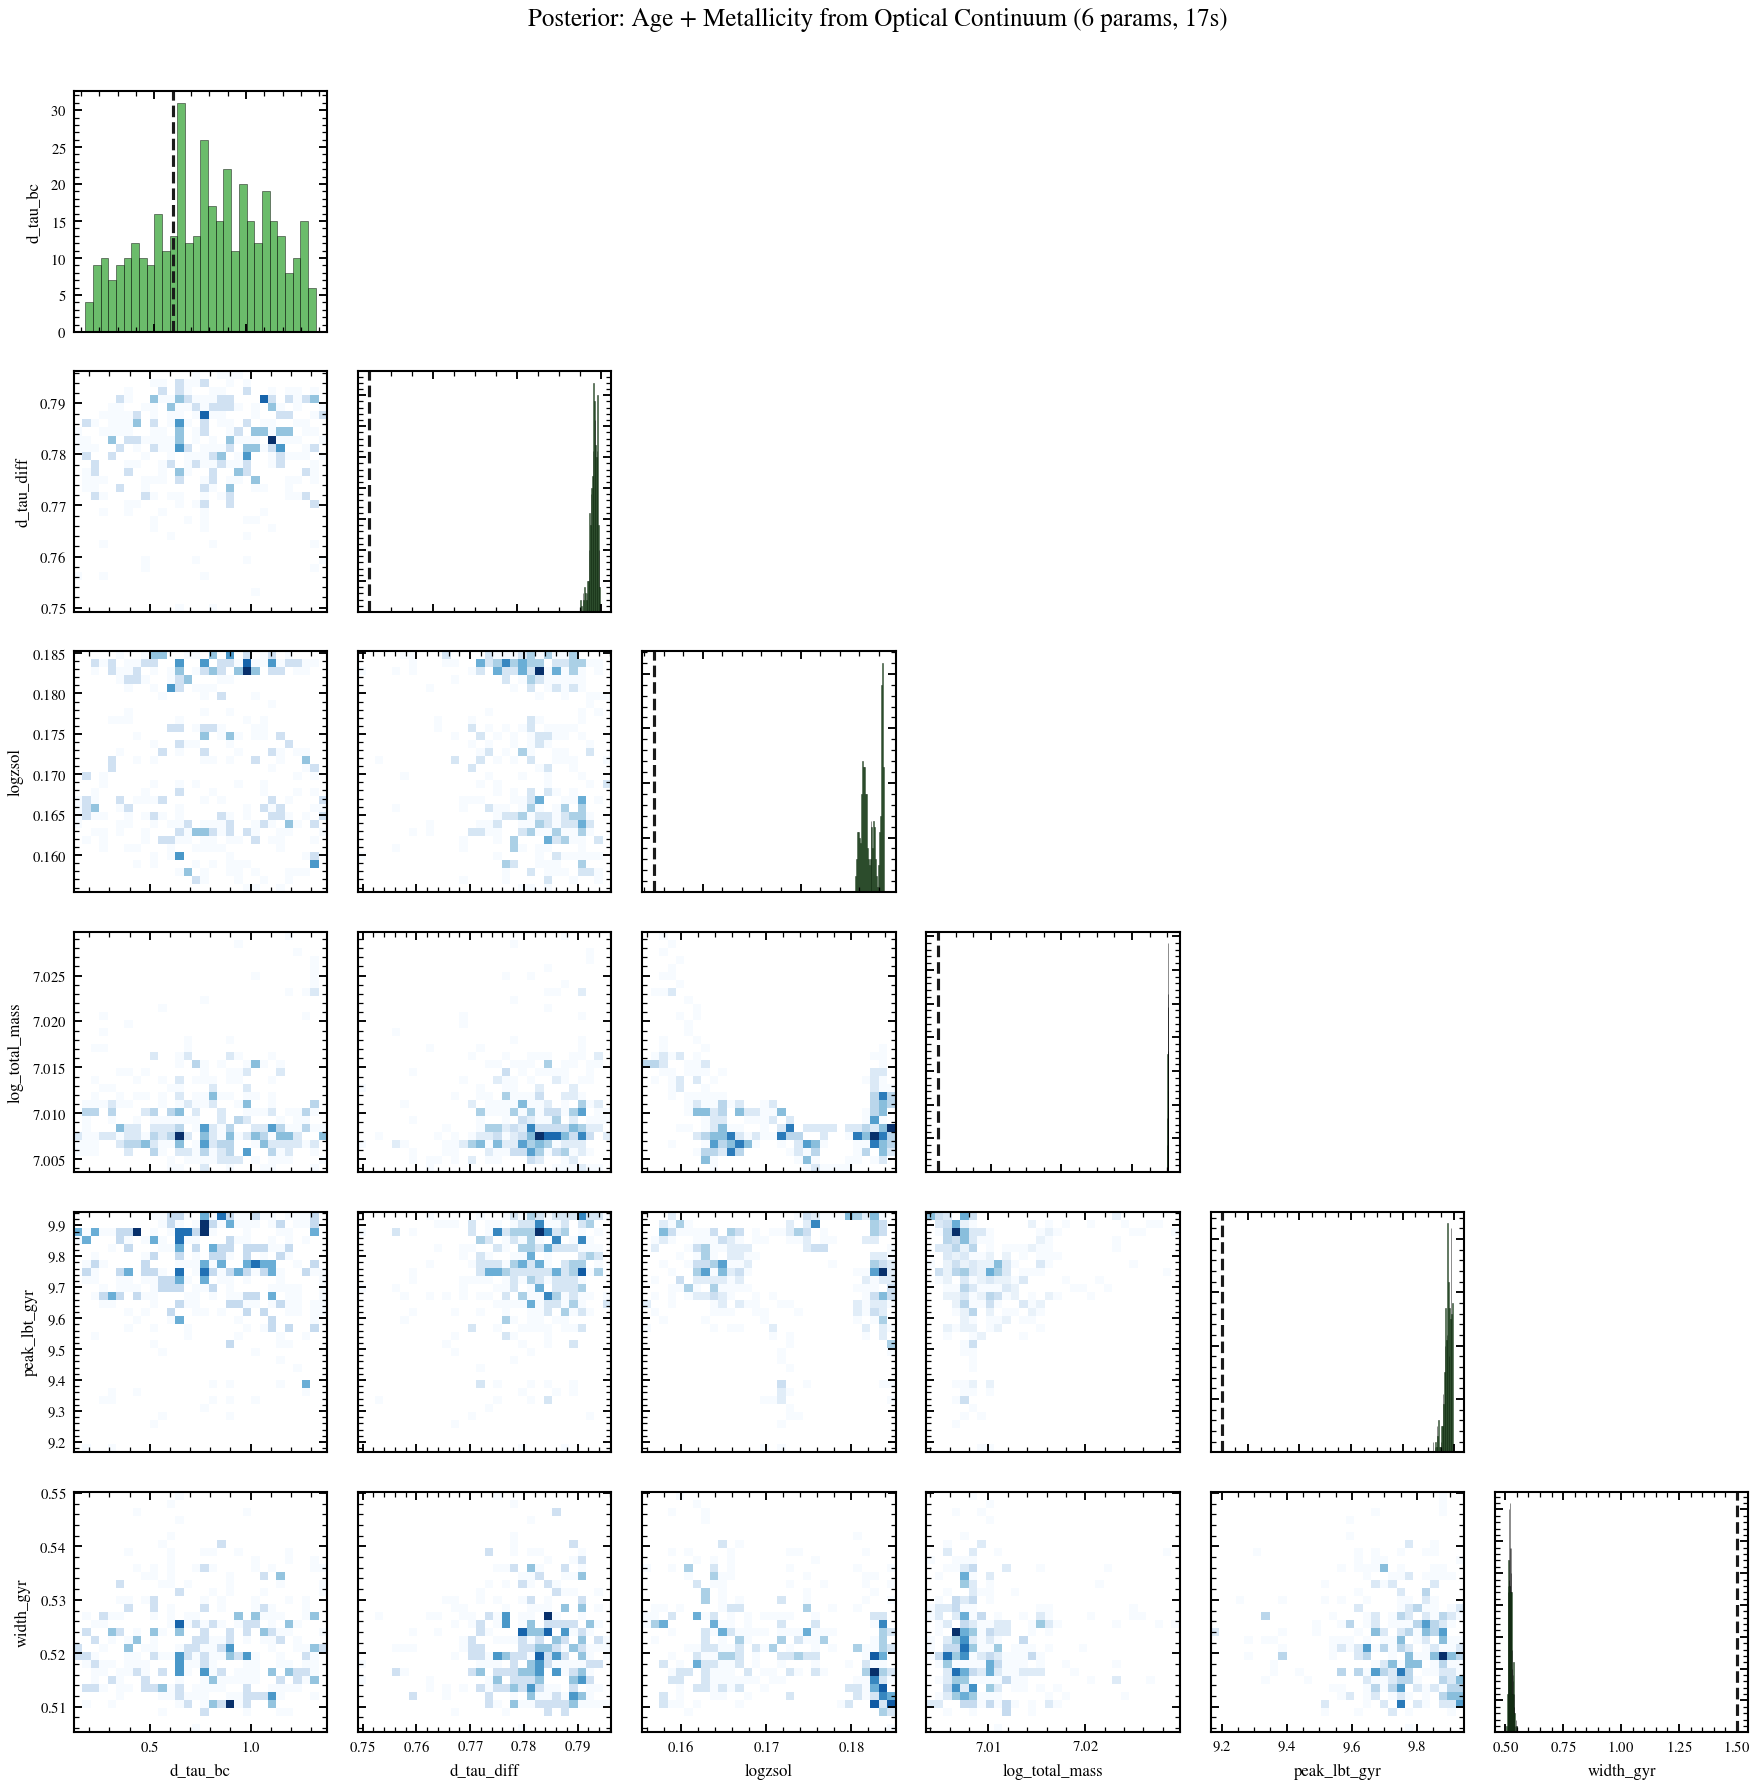

In [13]:
# Plot: corner plot
# Lightweight manual corner. ``plot_corner_comparison`` (corner.py KDE)
# OOMs on macOS jetsam at ~24 GB peak when stacked on a 1000-pixel
# NUTS graph. Histograms are bounded RSS and adequate for tutorial.
# Filter to actually-varying parameters: result.samples may include
# fixed-as-constant chains (std == 0) which create empty corner cells.
free_p = [
    k for k in result_spec.samples.keys()
    if float(np.std(np.asarray(result_spec.samples[k]))) > 1e-12
]
n_free_p = len(free_p)
fig, axes = plt.subplots(n_free_p, n_free_p, figsize=(2 * n_free_p, 2 * n_free_p))
for i, ki in enumerate(free_p):
    xi = np.asarray(result_spec.samples[ki])
    truth_i = float(true_params[ki]) if ki in true_params else None
    for j, kj in enumerate(free_p):
        ax2 = axes[i, j]
        if i == j:
            ax2.hist(xi, bins=30, color=COLORS.get("mcmc_nuts", "C0"), alpha=0.7, edgecolor="k", lw=0.3)
            if truth_i is not None:
                ax2.axvline(truth_i, color=COLORS.get("truth", "C2"), ls="--", lw=1.5)
        elif j < i:
            xj = np.asarray(result_spec.samples[kj])
            ax2.hist2d(xj, xi, bins=30, cmap="Blues", cmin=1)
            tj = float(true_params[kj]) if kj in true_params else None
            if truth_i is not None and tj is not None:
                ax2.plot(tj, truth_i, "*", ms=11, color=COLORS.get("truth", "C2"), mec="k", mew=0.5)
        else:
            ax2.set_visible(False)
        if i < n_free_p - 1:
            ax2.set_xticklabels([])
        if j > 0:
            ax2.set_yticklabels([])
        if i == n_free_p - 1:
            ax2.set_xlabel(kj.replace("sfh_lnorm_", "").replace("dust_", "d_").replace("met_", ""), fontsize=8)
        if j == 0:
            ax2.set_ylabel(ki.replace("sfh_lnorm_", "").replace("dust_", "d_").replace("met_", ""), fontsize=8)
        ax2.tick_params(labelsize=7)
fig.suptitle(f"Posterior: Age + Metallicity from Optical Continuum ({spec_param.n_free} params, {t_nuts:.0f}s)",
             y=1.001, fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "06_corner.png"), dpi=180, bbox_inches="tight")
print("Saved 06_corner.png", flush=True)

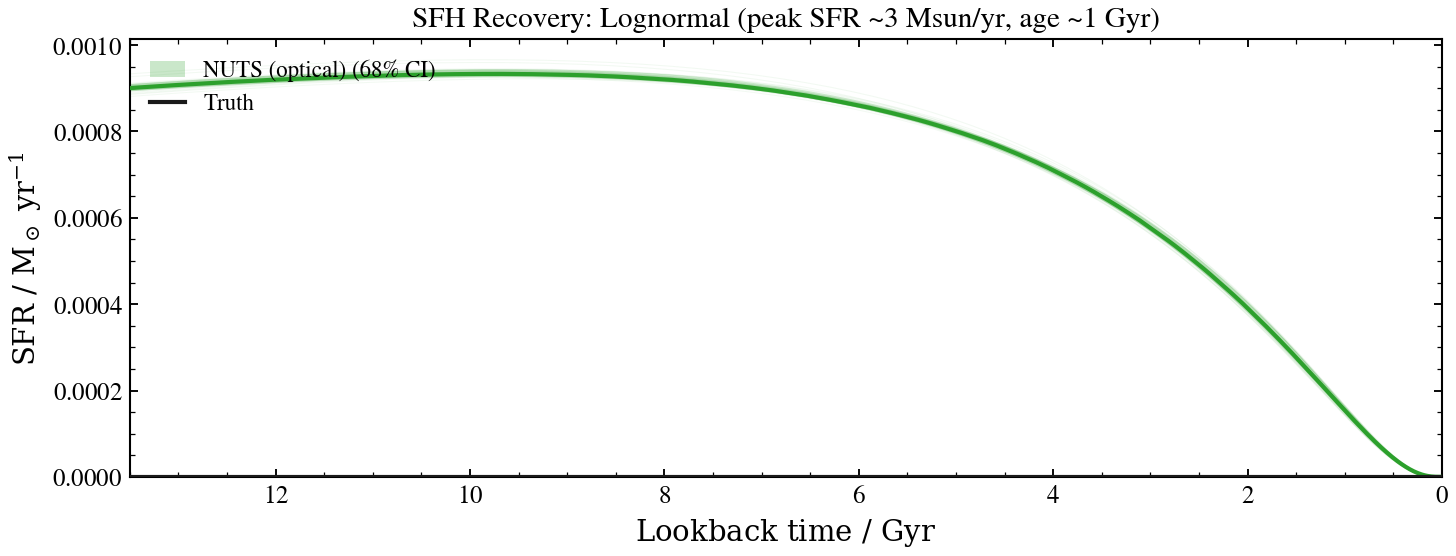

In [14]:
# Plot: sfh recovery
fig, ax = plt.subplots(figsize=(10, 4))
plot_sfh(model_spec, result_spec, true_params=true_params, ax=ax,
         color=COLORS.get("mcmc_nuts", "C0"), label="NUTS (optical)",
         method="NUTS")
ax.set_title(r"SFH Recovery: Lognormal (peak SFR ~3 Msun/yr, age ~1 Gyr)")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "06_sfh_recovery.png"), dpi=200, bbox_inches="tight")
plt.show()

In [15]:
print("SUMMARY")
print("Spectroscopic fitting (optical continuum only):")
print(f"  Grid:   {n_pix} pixels, {n_good} unmasked (8 emission lines masked)")
print(f"  Time:   {t_nuts:.1f}s (NUTS warmup + sampling)")
print("  Model:  lognormal SFH, Calzetti dust, solar metallicity priors")
print("  Result: Age + metallicity recovered from absorption features (Hβ, Mgb, 4000 Å break)")
print("\nKey insight: Emission lines must be masked to avoid continuum bias.")
print("Calibration floor (1%) marginalizes over instrumental uncertainty.")
print("Spectroscopy notebook complete: continuum-only SED fitting (optical absorption features)")

SUMMARY
Spectroscopic fitting (optical continuum only):
  Grid:   200 pixels, 195 unmasked (8 emission lines masked)
  Time:   17.5s (NUTS warmup + sampling)
  Model:  lognormal SFH, Calzetti dust, solar metallicity priors
  Result: Age + metallicity recovered from absorption features (Hβ, Mgb, 4000 Å break)

Key insight: Emission lines must be masked to avoid continuum bias.
Calibration floor (1%) marginalizes over instrumental uncertainty.
Spectroscopy notebook complete: continuum-only SED fitting (optical absorption features)


In [16]:
tg.cite(result_spec)

component  name    citation                            
─────────  ──────  ────────────────────────────────────
framework  tengri  Cooray et al. (2026, Paper I)       
ssp        DSPS    Hearin et al. 2023 (MNRAS 521, 1741)
framework  JAX     Bradbury et al. 2018                
[3 results — framework]

% ────────────────────────────────────────────────────────────────
%  Citations for 3 components used by the model.  Paste into your .bib file.
% ────────────────────────────────────────────────────────────────

% [framework] tengri
@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

% [ssp] DSPS
@article{Hearin_2023,
  author = {{Hearin}, Andrew P. and {Chaves-Montero}, Jon{\'a}s and {Alarcon}, Alex and {Becker}, Matthew R. and {Benson}, Andrew},
  title = {{DSPS: Differentiable stellar populat